# ATP Tennis Match Analysis — Part 1: Data Collection & Cleaning

**Author:** Akinwale Agesin

This notebook covers the full data pipeline for the ATP Tennis Match Analysis project:
- **Data collection** from Jeff Sackmann's open-source ATP repository (2010–2024)
- **Data cleaning and feature engineering** — reshaping match-level data to player-match level, computing clutch index, first-serve percentage, fatigue metrics, and surface specialization
- **Exploratory data analysis** — visualizing key relationships before modeling

The two output files produced here — `players_df.csv` and `analysis_df.csv` — are loaded directly by `analysis.ipynb` for hypothesis testing and regression modeling.

**Data source:** [Jeff Sackmann ATP Repository](https://github.com/JeffSackmann/tennis_atp)

## 1. Data Collection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns

base_url = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/"

dfs = []
for year in range(2010,2025):
    df = pd.read_csv(f"{base_url}atp_matches_{year}.csv")
    df['tourney_year'] = year
    dfs.append(df)

matches_df = pd.concat(dfs,ignore_index = True)

#single DataFrame for analysis, but with a column marking the year. You can track by year and run multi-year analyses seamlessly, Can filter or group easily:No need to split dataframes, Memory-efficient and clean

cols_to_keep = ['tourney_id','tourney_name','tourney_date','tourney_year','surface',
                'winner_id','loser_id','winner_name','loser_name',
                'minutes','w_bpSaved','w_bpFaced','l_bpSaved','l_bpFaced',
                'winner_rank','loser_rank','score', 'w_1stIn','w_svpt','l_svpt','l_1stIn']

matches_df = matches_df[cols_to_keep]
matches_df.head(10)


,tourney_id,tourney_name,tourney_date,tourney_year,surface,winner_id,loser_id,winner_name,loser_name,minutes,...,w_bpFaced,l_bpSaved,l_bpFaced,winner_rank,loser_rank,score,w_1stIn,w_svpt,l_svpt,l_1stIn
0,2010-339,Brisbane,20100103,2010,Hard,104053,103429,Andy Roddick,Peter Luczak,84.0,...,3.0,3.0,5.0,7.0,77.0,7-6(5) 6-2,42.0,63.0,56.0,34.0
1,2010-339,Brisbane,20100103,2010,Hard,104958,104999,Carsten Ball,Mischa Zverev,70.0,...,0.0,7.0,10.0,134.0,78.0,7-5 6-1,30.0,57.0,66.0,34.0
2,2010-339,Brisbane,20100103,2010,Hard,104755,103813,Richard Gasquet,Jarkko Nieminen,121.0,...,8.0,7.0,11.0,52.0,88.0,6-3 4-6 6-4,51.0,97.0,85.0,58.0
3,2010-339,Brisbane,20100103,2010,Hard,105051,103781,Matthew Ebden,Jurgen Melzer,64.0,...,3.0,2.0,5.0,285.0,28.0,7-5 6-1,35.0,50.0,53.0,29.0
4,2010-339,Brisbane,20100103,2010,Hard,104607,105194,Tomas Berdych,Nick Lindahl,69.0,...,1.0,6.0,9.0,20.0,251.0,6-2 6-4,27.0,46.0,69.0,41.0
5,2010-339,Brisbane,20100103,2010,Hard,104571,103888,Marcos Baghdatis,Mardy Fish,101.0,...,1.0,3.0,6.0,42.0,55.0,7-5 7-5,32.0,62.0,77.0,36.0
6,2010-339,Brisbane,20100103,2010,Hard,103248,103566,Harel Levy,Michael Llodra,41.0,...,0.0,5.0,10.0,119.0,67.0,6-2 6-0,23.0,35.0,46.0,36.0
7,2010-339,Brisbane,20100103,2010,Hard,105064,103428,Thomaz Bellucci,Juan Ignacio Chela,105.0,...,10.0,2.0,8.0,36.0,73.0,6-3 3-6 6-1,58.0,87.0,71.0,38.0
8,2010-339,Brisbane,20100103,2010,Hard,103484,105023,James Blake,Sam Querrey,88.0,...,3.0,3.0,5.0,44.0,25.0,4-6 6-3 6-4,47.0,86.0,85.0,52.0
9,2010-339,Brisbane,20100103,2010,Hard,102967,104332,Marc Gicquel,Philipp Petzschner,50.0,...,0.0,1.0,5.0,58.0,80.0,6-3 6-1,27.0,38.0,46.0,21.0


## 2. Data Cleaning

In [16]:
# formatting turney days to Date Format
matches_df['tourney_date'] = pd.to_datetime(matches_df['tourney_date'], format='%Y%m%d')

matches_df = matches_df.sort_values('tourney_date')


winners_df = matches_df[['tourney_id','tourney_name','tourney_date','tourney_year','surface',
                      'winner_id','winner_name','minutes', 'winner_rank']].rename(
                      columns={'winner_id':'player_id','winner_name':'player_name'})

winners_df['win']= 1

winners_df['FS_pct']= matches_df['w_1stIn']/matches_df['w_svpt']
#calculating winners clutch
winners_df['clutch'] = (matches_df['w_bpSaved'] / matches_df['w_bpFaced']).fillna(0)


#losers dataframe
losers_df = matches_df[['tourney_id','tourney_name','tourney_date','tourney_year','surface',
                     'loser_id','loser_name','minutes', 'loser_rank']].rename(
                     columns={'loser_id':'player_id','loser_name':'player_name'})
                     
losers_df['win']= 0 
#calculating losers clutch 
losers_df['clutch'] = (matches_df['l_bpSaved'] / matches_df['l_bpFaced']).fillna(0)
losers_df['FS_pct']= matches_df['l_1stIn']/matches_df['l_svpt']

To prepare the ATP match dataset for player-level analysis, the tournament date was converted from numeric YYYYMMDD format into a proper datetime object and all matches were sorted chronologically.

The dataset was then reshaped from match-level to player-match-level by creating separate winner and loser dataframes, standardizing column names, and adding a binary `win` indicator. Two performance metrics were computed for each player-match observation:

- **`FS_pct`** — first-serve percentage (first serves in / total first serves attempted)
- **`clutch`** — break-point save rate (break points saved / break points faced), filled with 0 when no break points were faced

These steps produce clean, standardized player-match observations that can be merged into a unified analysis-ready dataset.

In [19]:
#Calculating match duration 
players_df['prev_minutes'] = players_df.groupby('player_id')['minutes'].shift(1)
players_df = players_df[players_df['prev_minutes'].notna()]
print(players_df['prev_minutes'].head())

2    113.0
3     58.0
4     56.0
5     86.0
6     57.0
Name: prev_minutes, dtype: float64


To measure fatigue effects, each player's previous match duration was computed by grouping observations by `player_id` and using `.shift(1)` to align each match with the minutes played in the immediately preceding match. Rows without a valid previous match duration were removed — these represent a player's first recorded match, from which no fatigue can be inferred.

In [17]:
#Computing recovery metrics
#Yearly FS_pct_avg
FS_pct_avg = (players_df
    .groupby(['player_id', 'tourney_year'])['FS_pct']
    .mean()
    .reset_index()
    .rename(columns={'FS_pct': 'FS_pct_avg'}))

players_df = players_df.merge(FS_pct_avg,on=['player_id', 'tourney_year'],how='left')

#FS_pct_diff for each match (match-level deviation from yearly avg)
players_df['FS_pct_diff']= players_df['FS_pct']- players_df['FS_pct_avg']

players_df = players_df.sort_values(by=['player_id','tourney_date'])

#Next-match's 1) outcome 2) FS_pct_diff and 3) year
players_df['next_win'] = players_df.groupby('player_id')['win'].shift(-1)
players_df['next_FS_pct_diff'] = players_df.groupby('player_id')['FS_pct_diff'].shift(-1)
players_df['next_year'] = players_df.groupby('player_id')['tourney_year'].shift(-1)

#### Recovery Metrics

To study physical recovery after fatiguing matches, serving performance in the next match is compared against each player's own typical level for that season.

**Yearly baseline (`FS_pct_avg`):** Average first-serve percentage across all matches in a given season — representing each player's normal serving performance.

**Match-level deviation (`FS_pct_diff`):** The difference between a player's serve percentage in a specific match and their yearly average. Positive values indicate above-average serving; negative values indicate below-average serving.

**Next-match variables** (created by shifting forward within each player's timeline):
- `next_win` — whether the player won the match immediately following
- `next_FS_pct_diff` — how well they served in that next match relative to their norm
- `next_year` — the season of the next match, used to enforce same-season comparisons

Together, these features enable the H2 regression: does serving above average after a fatiguing match increase the probability of winning the recovery match?

In [6]:
# Create a unified player rank variable
players_df["rank"] = players_df["winner_rank"].fillna(players_df["loser_rank"])

# Compute match-level rank difference: loser_rank - winner_rank
rank_summary = (
    players_df
    .groupby(["tourney_id", "tourney_date", "surface"], as_index=False)
    .agg(
        winner_rank_match=("winner_rank", "min"),  # non-missing winner_rank in that match
        loser_rank_match=("loser_rank", "min")     # non-missing loser_rank in that match
    )
)

rank_summary["rank_diff"] = rank_summary["loser_rank_match"] - rank_summary["winner_rank_match"]

# Merge back to players_df so each player-match has the same match-level rank_diff
players_df = players_df.merge(
    rank_summary[["tourney_id", "tourney_date", "surface", "rank_diff"]],
    on=["tourney_id", "tourney_date", "surface"],
    how="left"
)

# Surface experience: proportion of a player's matches on each surface
players_df["match_count_player"] = players_df.groupby("player_id")["tourney_id"].transform("count")
players_df["match_count_player_surface"] = players_df.groupby(["player_id", "surface"])["tourney_id"].transform("count")
players_df["surface_experience"] = players_df["match_count_player_surface"] / players_df["match_count_player"]


# Filter to reasonable subset for modeling:
# - non-missing rank_diff and surface_experience
# - non-missing clutch, prev_minutes, and rank
analysis_df = players_df.copy()

analysis_df = analysis_df[
    analysis_df["rank_diff"].notna()
    & analysis_df["surface_experience"].notna()
    & analysis_df["clutch"].notna()
    & analysis_df["prev_minutes"].notna()
    & analysis_df["rank"].notna()
]

analysis_df.head()

,tourney_id,tourney_name,tourney_date,tourney_year,surface,player_id,player_name,minutes,winner_rank,win,FS_pct,clutch,loser_rank,rest_days,prev_minutes,rank,rank_diff,match_count_player,match_count_player_surface,surface_experience
0,2014-414,Hamburg,2014-07-14,2014,Clay,100644,Alexander Zverev,124.0,285.0,1,0.536585,0.636364,NaN,0.0,120.0,285.0,0.0,583,180.0,0.308748
1,2014-414,Hamburg,2014-07-14,2014,Clay,100644,Alexander Zverev,113.0,285.0,1,0.611765,0.666667,NaN,0.0,124.0,285.0,0.0,583,180.0,0.308748
2,2014-414,Hamburg,2014-07-14,2014,Clay,100644,Alexander Zverev,58.0,285.0,1,0.568182,1.000000,NaN,0.0,113.0,285.0,0.0,583,180.0,0.308748
3,2014-414,Hamburg,2014-07-14,2014,Clay,100644,Alexander Zverev,56.0,NaN,0,0.450000,0.375000,285.0,0.0,58.0,285.0,0.0,583,180.0,0.308748
4,2014-439,Umag,2014-07-21,2014,Clay,100644,Alexander Zverev,86.0,NaN,0,0.596491,0.333333,161.0,7.0,56.0,161.0,0.0,583,180.0,0.308748


In the raw ATP data, ranking information is split into `winner_rank` and `loser_rank` because the data are organized at the match level. After reshaping to player-match level, each row only has a value in one of these columns. A unified `rank` variable is created by filling from whichever column is non-null.

A match-level ranking gap (`rank_diff`) is computed as `loser_rank - winner_rank` and merged back so both competitors in each match share the same value.

Surface specialization (`surface_experience`) is calculated as the proportion of each player's career matches played on the surface of the current match — a proxy for how comfortable and experienced a player is on that surface.

Finally, the dataset is filtered to retain only observations with complete values for all modeling features, producing `analysis_df` — the regression-ready dataset used in `analysis.ipynb`.

In [12]:
# Save both output files — loaded by analysis.ipynb
players_df.to_csv('players_df.csv', index=False)
analysis_df.to_csv('analysis_df.csv', index=False)
print(f"Saved players_df:  {players_df.shape[0]:,} rows x {players_df.shape[1]} cols")
print(f"Saved analysis_df: {analysis_df.shape[0]:,} rows x {analysis_df.shape[1]} cols")

## 3. Exploratory Data Analysis

### 3.1 Clutch Performance vs. Win Probability

/var/folders/7r/0f15dh317p31_mxm_s5xz4wm0000gn/T/ipykernel_14551/1915493545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_by_bin = players_df.groupby('clutch_bin')['win'].mean()


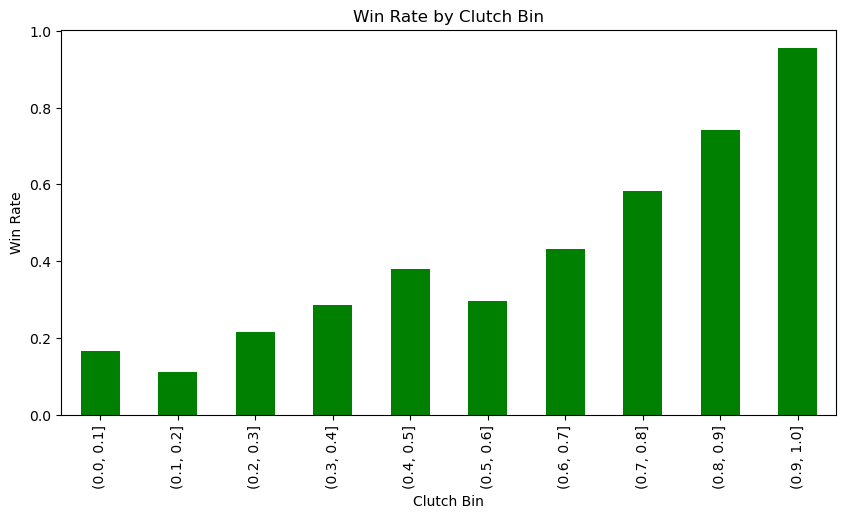

In [9]:
players_df['clutch_bin'] = pd.cut(players_df['clutch'], bins=np.linspace(0,1,11))
win_rate_by_bin = players_df.groupby('clutch_bin')['win'].mean()

plt.figure(figsize=(10,5))
win_rate_by_bin.plot(kind='bar', color='green')
plt.title("Win Rate by Clutch Bin")
plt.xlabel("Clutch Bin")
plt.ylabel("Win Rate")
plt.show()

Clutch values are binned into ten evenly spaced intervals between 0 and 1, and the average win rate within each bin is plotted as a bar chart.

The pattern is strongly upward-sloping: players with very low clutch values (0.0–0.2) win fewer than 20% of their matches, while those with clutch values above 0.8 win roughly 75–95% of the time. This provides strong empirical motivation for including clutch as a predictor in the H1 regression model.

### 3.2 First-Serve Percentage vs. Win Probability

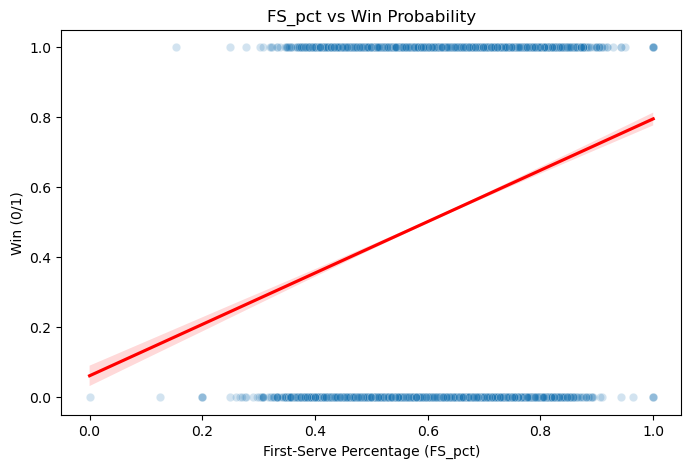

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='FS_pct', y='win', data=players_df, alpha=0.2)
sns.regplot(x='FS_pct', y='win', data=players_df, scatter=False, color='red')
plt.title("FS_pct vs Win Probability")
plt.xlabel("First-Serve Percentage (FS_pct)")
plt.ylabel("Win (0/1)")
plt.show()

A scatterplot of first-serve percentage (`FS_pct`) against the binary win indicator, overlaid with a regression line, shows a clear positive relationship: players with higher first-serve percentages win more often. This motivates using `FS_pct_diff` as the recovery proxy in H2.

### 3.3 Ranking Difference vs. Win Probability

/var/folders/7r/0f15dh317p31_mxm_s5xz4wm0000gn/T/ipykernel_14551/920988989.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_rankdiff = analysis_df.groupby('rank_diff_bin')['win'].mean()


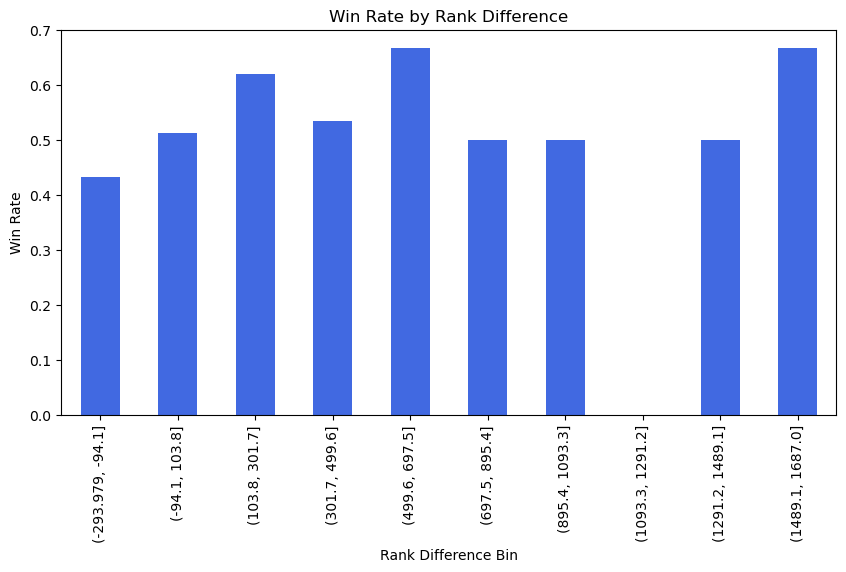

In [14]:
analysis_df['rank_diff_bin'] = pd.cut(analysis_df['rank_diff'], bins=10)

win_rate_rankdiff = analysis_df.groupby('rank_diff_bin')['win'].mean()

plt.figure(figsize=(10,5))
win_rate_rankdiff.plot(kind='bar', color='royalblue')
plt.title("Win Rate by Rank Difference")
plt.xlabel("Rank Difference Bin")
plt.ylabel("Win Rate")
plt.show()

`rank_diff` is binned into ten intervals and average win rates per bin are plotted. Unlike clutch or first-serve percentage, the relationship is not strictly monotonic — win rates fluctuate between roughly 0.45 and 0.67 across bins, suggesting that ranking difference alone does not cleanly predict outcomes. This motivates the interaction term in the H3 regression model.